<a href="https://colab.research.google.com/github/alearecuest/anyoneai-exercises-sprint_2/blob/main/15_1_2_THEORY_MLP_for_images_with_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLP for images with Keras

In this notebook I will show you how to build and train a MLP for image classification and regression usign MNIST dataset.

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt

%matplotlib inline

## Load the data

In [ ]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f'x_train.shape = {x_train.shape} - y_train.shape = {y_train.shape}')
print(f'x_test.shape = {x_test.shape} - y_test.shape = {y_test.shape}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train.shape = (60000, 28, 28) - y_train.shape = (60000,)
x_test.shape = (10000, 28, 28) - y_test.shape = (10000,)


In [ ]:
x_train.shape[1] * x_train.shape[2]

784

In [ ]:
y_train[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

## Feature Engineering

In [ ]:
# It's common to use MinMax(0,1) normalization for images
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255

# We can feed our MLP with squared images, we must flatten them first
x_train = x_train.reshape(len(x_train), -1)
x_test = x_test.reshape(len(x_test), -1)
print(f'New x_train.shape: {x_train.shape}')
print(f'New x_test.shape: {x_test.shape}')


New x_train.shape: (60000, 784)
New x_test.shape: (10000, 784)


In [ ]:
x_train[0].shape

(784,)

In [ ]:
from ipywidgets import interact
import ipywidgets as widgets

plt.gray()

@interact(i=(0, len(x_train)-1))
def show_image(i):
    plt.imshow(x_train[i].reshape(28, 28))
    plt.title(y_train[i])
    plt.show()

<Figure size 640x480 with 0 Axes>

interactive(children=(IntSlider(value=29999, description='i', max=59999), Output()), _dom_classes=('widget-int…

## Building the model

It will have:

    - 2 hidden layers with 16 neurons each
    - 1 output layer with 10 neurons (1 for each class)
    - Batch size of 32 during training


In [ ]:
x_train[0].shape

(784,)

In [ ]:
input_shape = x_train[0].shape

# Build the model
model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Dense(16, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(10, activation='softmax')
    ]
)

# Now we must compile it
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

print('Summary:')
model.summary()

Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,002 (50.79 KB)

 Trainable params: 13,002 (50.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
(784+1)*16 + (16+1)*16 + (16+1)*10

13002

### Training the model

In [ ]:
print("\nTraining...")
history = model.fit(
    x=x_train,
    y=y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[
      keras.callbacks.EarlyStopping(patience=2, ),
      keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                                      save_best_only=True)

    ]
)


Training...
Epoch 1/15
1493/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6621 - loss: 1.0422

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6628 - loss: 1.0402 - val_accuracy: 0.9143 - val_loss: 0.3034
Epoch 2/15
1493/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8914 - loss: 0.3654

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8914 - loss: 0.3653 - val_accuracy: 0.9304 - val_loss: 0.2481
Epoch 3/15
1479/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9086 - loss: 0.3109

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9087 - loss: 0.3108 - val_accuracy: 0.9401 - val_loss: 0.2207
Epoch 4/15
1490/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9201 - loss: 0.2672

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9201 - loss: 0.2672 - val_accuracy: 0.9414 - val_loss: 0.2121
Epoch 5/15
1488/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9271 - loss: 0.2446

...

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9363 - loss: 0.2157 - val_accuracy: 0.9474 - val_loss: 0.1916
Epoch 8/15
1491/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9363 - loss: 0.2082

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9363 - loss: 0.2082 - val_accuracy: 0.9492 - val_loss: 0.1812
Epoch 9/15
1483/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9425 - loss: 0.1925

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9424 - loss: 0.1926 - val_accuracy: 0.9484 - val_loss: 0.1764
Epoch 10/15
1487/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9442 - loss: 0.1865

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9442 - loss: 0.1866 - val_accuracy: 0.9515 - val_loss: 0.1733
Epoch 11/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9465 - loss: 0.1797 - val_accuracy: 0.9499 - val_loss: 0.1776
Epoch 12/15
1492/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9460 - loss: 0.1749

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9460 - loss: 0.1750 - val_accuracy: 0.9514 - val_loss: 0.1718
Epoch 13/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9474 - loss: 0.1708 - val_accuracy: 0.9503 - val_loss: 0.1789
Epoch 14/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9472 - loss: 0.1717 - val_accuracy: 0.9520 - val_loss: 0.1734


### Let's see some plots

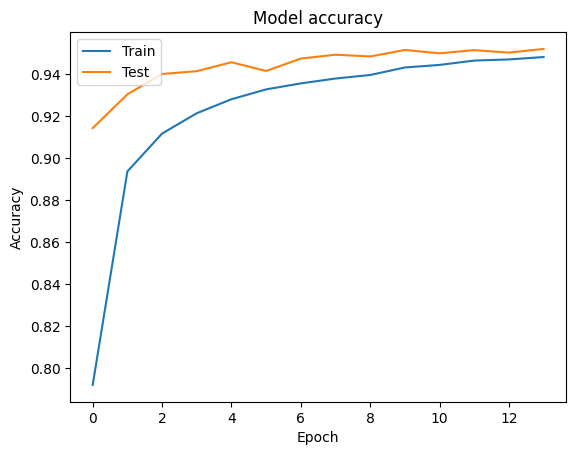

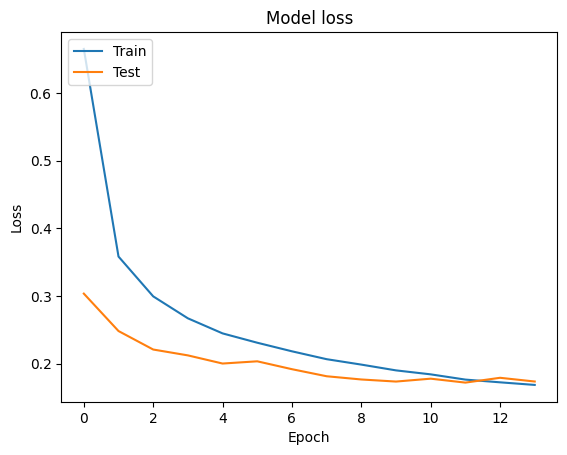

In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

### Using the model


In [ ]:
x_test[0].shape

(784,)

In [ ]:
x_test[0].reshape(1, -1).shape

(1, 784)

In [ ]:
prediction = model.predict(x_test[0].reshape(1, -1))
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step


array([[3.5600622e-09, 4.3567269e-08, 2.6143642e-04, 3.6568467e-03,
        1.0657285e-09, 5.1136212e-08, 3.9330430e-14, 9.9511349e-01,
        3.9846504e-06, 9.6410298e-04]], dtype=float32)

In [ ]:
pred_class = prediction.argmax(axis=1)[0]
pred_class

np.int64(7)

In [ ]:
prediction[0][pred_class]

np.float32(0.9951135)

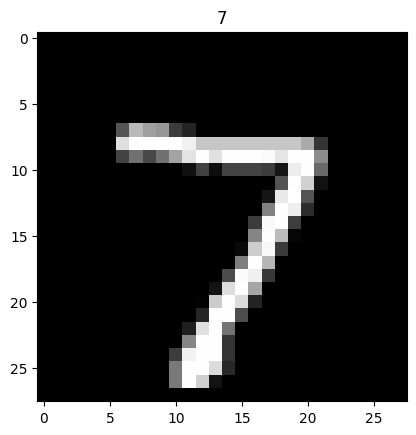

In [ ]:
plt.imshow(x_test[0].reshape(28, 28))
plt.title(y_test[0])
plt.show()

Evaluate the model on all the testing set, never used yet

In [ ]:
# Predict over test
y_test_pred = model.predict(x_test)

# Get predicted class from probabilities
y_test_pred_cat = y_test_pred.argmax(axis=1)

# Evaluamos el accuracy score
accuracy_score(y_true=y_test, y_pred=y_test_pred_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


0.9544

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true=y_test, y_pred=y_test_pred_cat))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.98      0.98      0.98      1135
           2       0.97      0.95      0.96      1032
           3       0.94      0.94      0.94      1010
           4       0.96      0.96      0.96       982
           5       0.96      0.91      0.93       892
           6       0.95      0.98      0.97       958
           7       0.97      0.95      0.96      1028
           8       0.92      0.96      0.94       974
           9       0.95      0.93      0.94      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



---

# MLP for regression

Let's now think this problem as a regression. We will predict one number between 0 and 9 instead a of class.


In [ ]:
# Input shape will be the same
input_shape = x_train[0].shape

# Output shape now is different!
# Note: Activation function in the output layer
# can't be softmax in this case

# Define the model
model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Dense(16, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='linear')
    ]
)

optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mae'])

print('Summary:')
model.summary()


Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,849 (50.19 KB)

 Trainable params: 12,849 (50.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("\nTraining...")
history = model.fit(
    x=x_train,
    y=y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
)



Training...
Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 4.9032 - mae: 1.6557 - val_loss: 1.7978 - val_mae: 0.9588
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.6748 - mae: 0.9256 - val_loss: 1.2949 - val_mae: 0.7875
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 1.2450 - mae: 0.7650 - val_loss: 1.0819 - val_mae: 0.6872
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.0415 - mae: 0.6738 - val_loss: 0.9560 - val_mae: 0.6226
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.8887 - mae: 0.6032 - val_loss: 0.9046 - val_mae: 0.5891
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.8035 - mae: 0.5562 - val_loss: 0.8288 - val_mae: 0.5523
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.7543 - mae: 0.5320 - val_loss: 0.8106 - val_mae: 0.5411
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.7084 - mae: 0.5103 - val_loss: 0.8219 - val_mae: 0.5385
Epoch 9/15
1500/1500 ━━━━━━

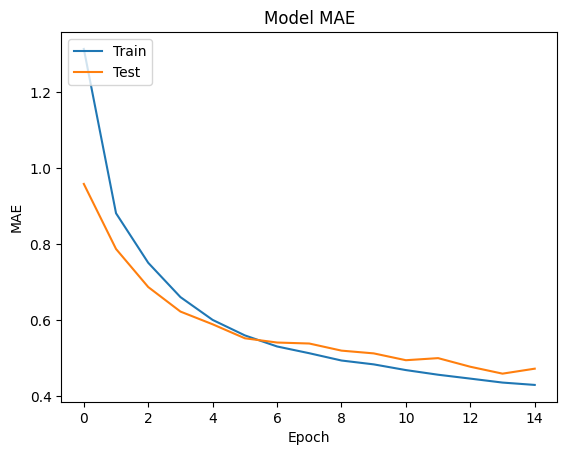

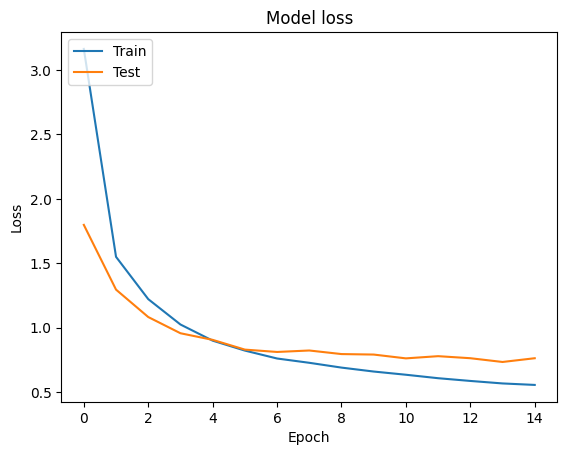

In [ ]:
# Plot training & validation MAE values
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('Model MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [ ]:
prediction = model.predict(x_test[1].reshape(1, -1))
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step


array([[1.5295928]], dtype=float32)

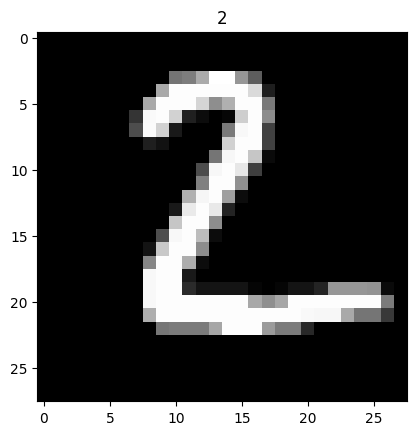

In [ ]:
plt.imshow(x_test[1].reshape(28, 28))
plt.title(y_test[1])
plt.show()